# Exploratory data analysis: MuReD





In [1]:
import hashlib
import io
import re
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

ROOT = Path.cwd()
TABLE_FILES = {"train": ROOT / "phase0" / "source" / "train_data.csv",
               "val": ROOT / "phase0" / "source" / "val_data.csv"}
IMAGES = ROOT / "images"
OUT = ROOT / "eda"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
STATS_CACHE = OUT / "image_stats.csv"
SIG_CACHE = OUT / "image_signatures.npy"

# Label codes as used by MuReD.
LABEL_NAMES = {
    "DR": "diabetic retinopathy", "NORMAL": "normal", "MH": "media haze",
    "ODC": "optic disc cupping", "TSLN": "tessellation",
    "ARMD": "age-related macular degeneration", "DN": "drusen", "MYA": "myopia",
    "BRVO": "branch retinal vein occlusion", "ODP": "optic disc pallor",
    "CRVO": "central retinal vein occlusion", "CNV": "choroidal neovascularization",
    "RS": "retinitis", "ODE": "optic disc edema", "LS": "laser scars",
    "CSR": "central serous retinopathy", "HTR": "hypertensive retinopathy",
    "ASR": "arteriosclerotic retinopathy", "CRS": "chorioretinitis", "OTHER": "other (catch-all)",
}
SOURCES = ["aria", "rfmid", "stare"]
SOURCE_COLORS = {"aria": "#4C78A8", "rfmid": "#F58518", "stare": "#54A24B"}
RNG_SEED = 0

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True})


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=150)

## 1. Label tables: structure and integrity

In [2]:
frames = []
for name, path in TABLE_FILES.items():
    f = pd.read_csv(path, dtype={"ID": str})
    f.insert(1, "table", name)
    frames.append(f)
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    print(f"{name:5s}: {len(f):5d} rows | sha256 {digest}")
raw = pd.concat(frames, ignore_index=True)
LABELS = [c for c in raw.columns if c not in ("ID", "table")]

print(f"\nlabels ({len(LABELS)}): {LABELS}")
print("missing values:", int(raw.isna().sum().sum()))
print("values outside {0, 1}:", int((~raw[LABELS].isin([0, 1])).sum().sum()))
for name in TABLE_FILES:
    part = raw[raw["table"] == name]
    print(f"duplicate IDs inside {name}:", int(part["ID"].duplicated().sum()))
shared = set(raw.loc[raw["table"] == "train", "ID"]) & set(raw.loc[raw["table"] == "val", "ID"])
print("IDs in both tables:", len(shared))
print("rows with no positive label:", int((raw[LABELS].sum(axis=1) == 0).sum()))
print(f"total images in the tables: {len(raw)}")

train:  1764 rows | sha256 a40f340cba6dd7141a3194214434b51484186dec8903e25d096853b995a5a7ee
val  :   444 rows | sha256 d7967f05e7f422002e071cdd5288cf822185ac86ad9f237fe698b29915223fb7

labels (20): ['DR', 'NORMAL', 'MH', 'ODC', 'TSLN', 'ARMD', 'DN', 'MYA', 'BRVO', 'ODP', 'CRVO', 'CNV', 'RS', 'ODE', 'LS', 'CSR', 'HTR', 'ASR', 'CRS', 'OTHER']
missing values: 0
values outside {0, 1}: 0
duplicate IDs inside train: 0
duplicate IDs inside val: 0
IDs in both tables: 0
rows with no positive label: 0
total images in the tables: 2208


## 2. Source datasets from the image IDs

MuReD merges three public datasets. Each has ots own ID 



In [3]:
ARIA_RE = re.compile(r"^(?:\((\d+)\))?aria_([acd])_(.+)$")


def id_source(image_id):
    if ARIA_RE.match(image_id):
        return "aria"
    if re.fullmatch(r"im\d{4}", image_id):
        return "stare"
    if re.fullmatch(r"\d+", image_id):
        return "rfmid"
    return "unknown"


raw["source"] = raw["ID"].map(id_source)
if (raw["source"] == "unknown").any():
    raise ValueError(f"unparsed IDs: {raw.loc[raw['source'] == 'unknown', 'ID'].tolist()[:10]}")

by_source = pd.crosstab(raw["source"], raw["table"], margins=True, margins_name="total")
by_source["val share"] = (by_source["val"] / by_source["total"]).round(3)
display(by_source)

table,train,val,total,val share
source,,,,
aria,111,18,129,0.140
rfmid,1369,360,1729,0.208
stare,284,66,350,0.189
total,1764,444,2208,0.201


## 3. Label prevalence

In [4]:
N = len(raw)
prev = pd.DataFrame({
    "name": [LABEL_NAMES[l] for l in LABELS],
    "positives": [int(raw[l].sum()) for l in LABELS],
}, index=LABELS).sort_values("positives", ascending=False)
display(prev)


,name,positives
DR,diabetic retinopathy,495
NORMAL,normal,493
ODC,optic disc cupping,263
OTHER,other (catch-all),261
MH,media haze,169
DN,drusen,162
ARMD,age-related macular degeneration,158
TSLN,tessellation,156
MYA,myopia,89
BRVO,branch retinal vein occlusion,79


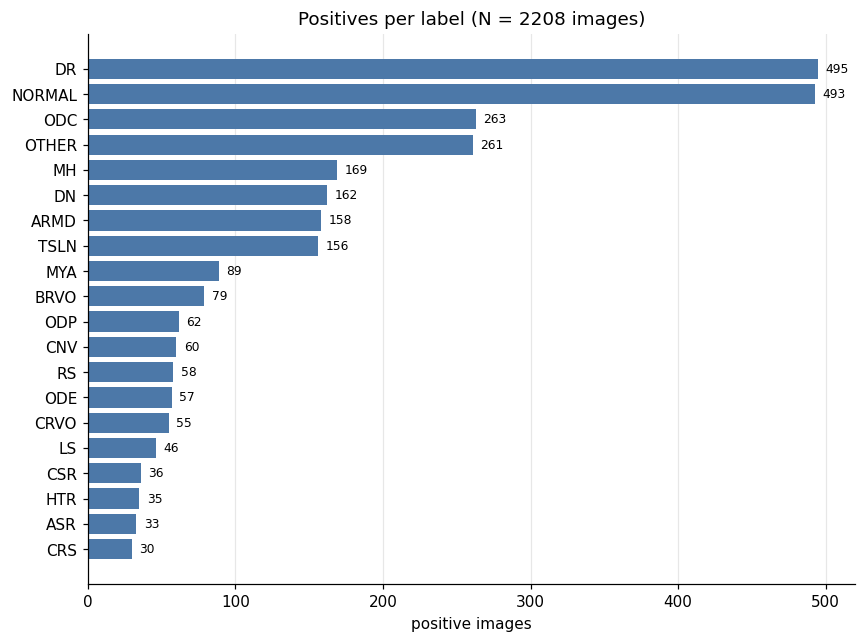

In [5]:
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(prev.index, prev["positives"], color="#4C78A8")
for y, n in enumerate(prev["positives"]):
    ax.text(n + 5, y, str(n), va="center", fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("positive images")
ax.set_title(f"Positives per label (N = {N} images)")
ax.grid(axis="y", visible=False)
savefig(fig, "01_label_positives")
plt.show()


## 4. Co-occurrence

The left panel counts images that carry both labels. The right panel shows P(column | row): of the images with the row label, the share that also carries the column label.

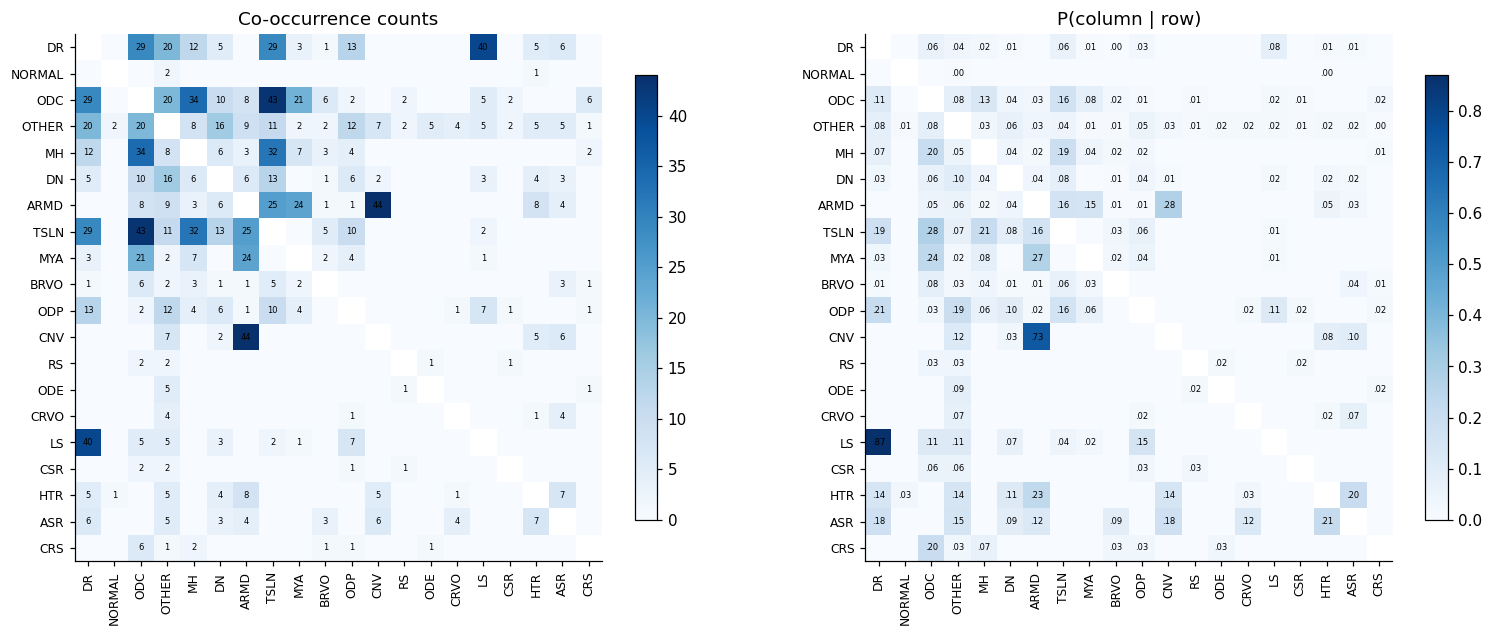

In [6]:
order = list(prev.index)
X = raw[order].values.astype(int)
co = pd.DataFrame(X.T @ X, index=order, columns=order)
cond = co.div(np.diag(co), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
for ax, mat, title, fmt in [(axes[0], co, "Co-occurrence counts", "d"),
                            (axes[1], cond, "P(column | row)", ".2f")]:
    shown = mat.copy().astype(float)
    np.fill_diagonal(shown.values, np.nan)
    im = ax.imshow(shown, cmap="Blues")
    ax.set_xticks(range(len(order)), order, rotation=90, fontsize=8)
    ax.set_yticks(range(len(order)), order, fontsize=8)
    ax.grid(False)
    for i in range(len(order)):
        for j in range(len(order)):
            v = mat.iloc[i, j]
            if i != j and v > 0:
                ax.text(j, i, format(v, fmt).lstrip("0") if fmt != "d" else str(v),
                        ha="center", va="center", fontsize=5.5)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.7)
savefig(fig, "02_cooccurrence")
plt.show()

## 5. Labels by source

A label that exists in only one source is tied to that source's camera, population, and grading practice. A model can then learn the source instead of the disease.

In [7]:
src_tab = raw.groupby("source")[order].sum().T
src_tab["total"] = src_tab.sum(axis=1)
for s in SOURCES:
    src_tab[f"% of {s} images"] = (100 * src_tab[s] / (raw["source"] == s).sum()).round(1)
src_tab["single source"] = (src_tab[SOURCES] > 0).sum(axis=1) == 1
display(src_tab)

single = src_tab.index[src_tab["single source"]].tolist()
print(f"labels found in only one source ({len(single)}): {single}")

source,aria,rfmid,stare,total,% of aria images,% of rfmid images,% of stare images,single source
DR,52,356,87,495,40.3,20.6,24.9,False
NORMAL,57,400,36,493,44.2,23.1,10.3,False
ODC,0,263,0,263,0.0,15.2,0.0,True
OTHER,0,171,90,261,0.0,9.9,25.7,False
MH,0,169,0,169,0.0,9.8,0.0,True
DN,0,133,29,162,0.0,7.7,8.3,False
ARMD,20,91,47,158,15.5,5.3,13.4,False
TSLN,0,156,0,156,0.0,9.0,0.0,True
MYA,0,89,0,89,0.0,5.1,0.0,True
BRVO,0,69,10,79,0.0,4.0,2.9,False


labels found in only one source (12): ['ODC', 'MH', 'TSLN', 'MYA', 'ODP', 'CNV', 'ODE', 'LS', 'CSR', 'HTR', 'ASR', 'CRS']


## 6. Image files

This section reads every image file once. It matches the files to the label tables and measures each image for section 7:

- **SHA-256** of the file bytes, for exact duplicates.
- **Field of view (FOV)**: pixels brighter than a grey level of 20. Fundus photographs are a bright disc on a black surround.
- **Layout signature**: the contrast-equalised (CLAHE) green channel of the FOV at 32 × 32 px, band-pass filtered so that the coarse vessel tree and optic disc dominate, then scaled to unit length.

Each image also gets an **acquisition group**: its source, with RFMiD split into its three image-size bands, which likely match different cameras.

The measurements are cached in `eda/image_stats.csv` and `eda/image_signatures.npy`. Delete them to recompute. The first pass over cold files takes several minutes; later passes take seconds.

In [8]:
files = sorted(p for p in IMAGES.iterdir() if p.is_file() and not p.name.startswith("."))
fdf = pd.DataFrame({"file": [p.name for p in files], "stem": [p.stem for p in files],
                    "ext": [p.suffix.lower() for p in files], "bytes": [p.stat().st_size for p in files]})
fdf["source"] = fdf["stem"].map(id_source)
fdf["in tables"] = fdf["stem"].isin(set(raw["ID"]))
missing_files = sorted(set(raw["ID"]) - set(fdf["stem"]))
print(f"image files: {len(fdf)} | table IDs without a file: {len(missing_files)} | "
      f"files without a label row: {int((~fdf['in tables']).sum())} "
      f"{fdf.loc[~fdf['in tables'], 'source'].value_counts().to_dict()}")

image files: 2451 | table IDs without a file: 0 | files without a label row: 243 {'rfmid': 191, 'stare': 38, 'aria': 14}


In [9]:
FOV_GREY = 20
STAT_SIDE = 512
SIG_SIDE = 32


def equalise(grey):
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(np.ascontiguousarray(grey))


def layout_signature(small, mask):
    x, y, w, h = cv2.boundingRect(mask.astype(np.uint8))
    g = equalise(small[y:y + h, x:x + w, 1])
    g = cv2.resize(g.astype(np.float32), (SIG_SIDE, SIG_SIDE), interpolation=cv2.INTER_AREA)
    m = cv2.resize(mask[y:y + h, x:x + w].astype(np.uint8), (SIG_SIDE, SIG_SIDE),
                   interpolation=cv2.INTER_NEAREST)
    m = cv2.erode(m, np.ones((5, 5), np.uint8)).astype(bool)
    hp = cv2.GaussianBlur(g, (0, 0), 0.7) - cv2.GaussianBlur(g, (0, 0), 3)
    hp[~m] = 0
    v = hp.flatten()
    v[m.flatten()] -= v[m.flatten()].mean()
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else v


def image_stats(path):
    data = path.read_bytes()
    arr = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_UNCHANGED)
    if arr is None:
        return {"file": path.name, "readable": False}, np.zeros(SIG_SIDE * SIG_SIDE, np.float32)
    if arr.dtype == np.uint16:
        arr = (arr / 257).astype(np.uint8)
    if arr.ndim == 2:
        arr = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
    elif arr.shape[2] == 4:
        arr = cv2.cvtColor(arr, cv2.COLOR_BGRA2BGR)
    h, w = arr.shape[:2]
    s = STAT_SIDE / max(h, w)
    small = cv2.resize(arr, (max(1, round(w * s)), max(1, round(h * s))), interpolation=cv2.INTER_AREA)
    grey = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    mask = cv2.morphologyEx((grey > FOV_GREY).astype(np.uint8), cv2.MORPH_OPEN,
                            np.ones((5, 5), np.uint8)).astype(bool)
    row = {"file": path.name, "readable": True, "width": w, "height": h,
           "sha256": hashlib.sha256(data).hexdigest(), "fov_fraction": float(mask.mean())}
    return row, layout_signature(small, mask).astype(np.float32)


cache_ok = False
if STATS_CACHE.exists() and SIG_CACHE.exists():
    cached = pd.read_csv(STATS_CACHE, dtype={"sha256": str})
    sig = np.load(SIG_CACHE)
    cache_ok = list(cached["file"]) == list(fdf["file"]) and len(sig) == len(cached)
if cache_ok:
    img = cached
    print(f"loaded {len(img)} rows from {STATS_CACHE.relative_to(ROOT)}")
else:
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(image_stats, files))
    img = pd.DataFrame([r for r, _ in results])
    sig = np.stack([v for _, v in results])
    img.to_csv(STATS_CACHE, index=False)
    np.save(SIG_CACHE, sig)
    print(f"measured {len(img)} images, cached to {STATS_CACHE.relative_to(ROOT)}")

img = fdf.merge(img, on="file")
print("unreadable files:", int((~img["readable"]).sum()))

loaded 2451 rows from eda/image_stats.csv
unreadable files: 0


In [10]:
def acq_group(row):
    if row["source"] != "rfmid":
        return row["source"]
    if row["height"] >= 2000:
        return "rfmid_large"
    if row["height"] >= 1450:
        return "rfmid_mid"
    return "rfmid_small"


img["acq_group"] = img.apply(acq_group, axis=1)
lab = img[img["in tables"]].merge(raw.drop(columns=["source"]), left_on="stem", right_on="ID")
display(img.groupby("acq_group").agg(files=("file", "size"), width_median=("width", "median"),
                                     height_median=("height", "median")))

,files,width_median,height_median
acq_group,,,
aria,143,740.0,575.0
rfmid_large,277,3415.0,2847.0
rfmid_mid,149,1470.0,1475.0
rfmid_small,1494,1390.0,1391.0
stare,388,648.0,565.0


## 7. Exact and near duplicates

Does the same eye appear more than once? If one photo of an eye is used for training and another photo of the same eye for testing, the model is tested on an eye it has already seen, and the test score is too high.


Finding same-eye pairs takes two steps:

1. **Shortlist.** Checking all 3 million pairs carefully is too slow. Two fast checks pick, for each image, the 3 images that look most like it: the layout signature from section 6, and matching keypoints (small distinctive spots, such as vessel branches).
2. **Check.** For each shortlisted pair, line the two images up on their matching keypoints, then compare the blood vessels. The vessel pattern of an eye works like a fingerprint. A pair counts as the same eye when at least 10 keypoints line up **and** the vessels agree (correlation of 0.15 or more). Pairs from two different source datasets cannot be the same eye, so they never count.

In [11]:
sha_groups = img[img.duplicated("sha256", keep=False)].groupby("sha256")["file"].apply(list)
print(f"exact duplicate groups: {len(sha_groups)} ({int(sha_groups.map(len).sum())} files)")
for files_ in sha_groups.head(10):
    print("  ", files_)

TOP_K = 3
SIFT_SIDE = 512
SIFT_FEATURES = 800
VOTE_FEATURES = 300
RATIO = 0.75
cv2.setRNGSeed(RNG_SEED)


def read_bgr(i):
    return cv2.imread(str(IMAGES / img["file"].iat[i]), cv2.IMREAD_COLOR)


def sift_features(arr_bgr):
    
    h, w = arr_bgr.shape[:2]
    s = SIFT_SIDE / max(h, w)
    small = cv2.resize(arr_bgr, (max(1, round(w * s)), max(1, round(h * s))), interpolation=cv2.INTER_AREA)
    grey = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    mask = cv2.erode((grey > FOV_GREY).astype(np.uint8) * 255, np.ones((21, 21), np.uint8))
    kp, desc = cv2.SIFT_create(nfeatures=SIFT_FEATURES).detectAndCompute(equalise(small[:, :, 1]), mask)
    if desc is None or not kp:
        return np.zeros((0, 2), np.float32), np.zeros((0, 128), np.uint8)
    order_ = np.argsort([-k.response for k in kp], kind="stable")
    pts = np.float32([kp[i].pt for i in order_])
    return pts, np.clip(np.rint(desc[order_]), 0, 255).astype(np.uint8)


with ThreadPoolExecutor(max_workers=8) as pool:
    feats = list(pool.map(lambda i: sift_features(read_bgr(i)), range(len(img))))
print(f"SIFT keypoints per image: median {int(np.median([len(p) for p, _ in feats]))}")

# Screen 1: layout signature.
with np.errstate(all="ignore"):  # Accelerate BLAS on macOS raises spurious matmul warnings
    S = sig.astype(np.float64) @ sig.astype(np.float64).T
np.fill_diagonal(S, -np.inf)
layout_nbrs = np.argsort(-S, axis=1)[:, :TOP_K]

# Screen 2: keypoint voting over a FLANN index of every image's strongest keypoints.
vote_desc = np.vstack([d[:VOTE_FEATURES] for _, d in feats]).astype(np.float32)
owner = np.concatenate([np.full(min(len(d), VOTE_FEATURES), i) for i, (_, d) in enumerate(feats)])
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=4), dict(checks=64))
flann.add([vote_desc])
flann.train()


def count_votes(matches, query_owner=None):
    # A keypoint votes for the image of its best match if that match beats the best match in any other image.
    votes = {}
    for q, row in enumerate(matches):
        a = query_owner[q] if query_owner is not None else -1
        others = [m for m in row if owner[m.trainIdx] != a]
        if len(others) < 2:
            continue
        best = others[0]
        rest = [m for m in others[1:] if owner[m.trainIdx] != owner[best.trainIdx]]
        if rest and best.distance < 0.8 * rest[0].distance:
            key = (a, int(owner[best.trainIdx])) if query_owner is not None else int(owner[best.trainIdx])
            votes[key] = votes.get(key, 0) + 1
    return votes


pair_votes = count_votes(flann.knnMatch(vote_desc, k=6), owner)
vote_frame = pd.DataFrame([(a, b, v) for (a, b), v in pair_votes.items()], columns=["i", "j", "votes"])
vote_nbrs = vote_frame.sort_values(["i", "votes"], ascending=[True, False]).groupby("i").head(TOP_K)

cand_pairs = {tuple(sorted((i, int(j)))) for i in range(len(img)) for j in layout_nbrs[i]}
n_layout = len(cand_pairs)
cand_pairs |= {tuple(sorted((int(r.i), int(r.j)))) for r in vote_nbrs.itertuples()}
cand_pairs = sorted(cand_pairs)
print(f"candidate pairs: {len(cand_pairs)} ({n_layout} from the layout screen, "
      f"{len(cand_pairs) - n_layout} more from the vote screen)")

exact duplicate groups: 0 (0 files)


SIFT keypoints per image: median 448


candidate pairs: 12190 (6384 from the layout screen, 5806 more from the vote screen)


In [12]:
RANSAC_PX = 8.0
SCALE_RANGE = (0.67, 1.5)
MIN_INLIERS = 6
ALIGN_MIN = 0.15      # vessel correlation needed to call a pair the same eye
VERIFY_INLIERS = 10   # keypoints that must line up


def fit_similarity(fa, fb):
    (pa, da), (pb, db) = fa, fb
    if len(da) < 8 or len(db) < 8:
        return 0, np.nan, None
    knn = cv2.BFMatcher(cv2.NORM_L2).knnMatch(da.astype(np.float32), db.astype(np.float32), k=2)
    good = [m for m, n in (x for x in knn if len(x) == 2) if m.distance < RATIO * n.distance]
    best = {}
    for m in good:  # one to one: many points matching one point is how unrelated images fake a fit
        if m.trainIdx not in best or m.distance < best[m.trainIdx].distance:
            best[m.trainIdx] = m
    good = list(best.values())
    if len(good) < MIN_INLIERS:
        return 0, np.nan, None
    M, inl = cv2.estimateAffinePartial2D(pa[[m.queryIdx for m in good]], pb[[m.trainIdx for m in good]],
                                         method=cv2.RANSAC, ransacReprojThreshold=RANSAC_PX,
                                         maxIters=5000, confidence=0.999)
    if M is None:
        return 0, np.nan, None
    return int(inl.sum()), float(np.sqrt(abs(np.linalg.det(M[:, :2])))), M


def vessel_map(arr_bgr):
    # Same 512 px frame as the SIFT keypoints, so a fitted transform applies directly.
    h, w = arr_bgr.shape[:2]
    s = SIFT_SIDE / max(h, w)
    small = cv2.resize(arr_bgr, (max(1, round(w * s)), max(1, round(h * s))), interpolation=cv2.INTER_AREA)
    g = equalise(small[:, :, 1]).astype(np.float32)
    v = g - cv2.GaussianBlur(g, (0, 0), 4)
    m = cv2.erode((cv2.cvtColor(small, cv2.COLOR_BGR2GRAY) > FOV_GREY).astype(np.uint8), np.ones((21, 21), np.uint8))
    return v, m


def alignment(arr_a, arr_b, M):
    # Correlation of vessel patterns after warping a onto b; share of b's field covered by the overlap.
    va, ma = vessel_map(arr_a)
    vb, mb = vessel_map(arr_b)
    size = (vb.shape[1], vb.shape[0])
    wa = cv2.warpAffine(va, M, size)
    wm = cv2.warpAffine(ma, M, size, flags=cv2.INTER_NEAREST)
    ov = (wm > 0) & (mb > 0)
    if ov.sum() < 2000:
        return np.nan, float(ov.sum() / max(1, mb.sum()))
    x = wa[ov] - wa[ov].mean()
    y = vb[ov] - vb[ov].mean()
    return float((x * y).sum() / np.sqrt((x * x).sum() * (y * y).sum())), float(ov.sum() / mb.sum())


def check_pair(p):
    i, j = p
    n, sc, M = fit_similarity(feats[i], feats[j])
    if M is None or not (SCALE_RANGE[0] <= sc <= SCALE_RANGE[1]):
        return n, sc, np.nan, np.nan
    r, ov = alignment(read_bgr(i), read_bgr(j), M)
    return n, sc, r, ov


cand = pd.DataFrame(cand_pairs, columns=["i", "j"])
cand["a"] = img["stem"].values[cand["i"]]
cand["b"] = img["stem"].values[cand["j"]]
cand["cross source"] = img["source"].values[cand["i"]] != img["source"].values[cand["j"]]
cand["similarity"] = S[cand["i"], cand["j"]].round(3)
cand["votes"] = [pair_votes.get((i, j), 0) + pair_votes.get((j, i), 0) for i, j in cand_pairs]
with ThreadPoolExecutor(max_workers=8) as pool:
    res_ = list(pool.map(check_pair, cand_pairs))
cand["inliers"], cand["scale"], cand["alignment"], cand["overlap"] = map(list, zip(*res_))
cand["duplicate"] = ((cand["alignment"] >= ALIGN_MIN) & (cand["inliers"] >= VERIFY_INLIERS)
                     & ~cand["cross source"])
cand[["a", "b", "cross source", "similarity", "votes", "inliers", "scale", "alignment", "overlap",
      "duplicate"]].to_csv(
    OUT / "duplicate_candidates.csv", index=False)
print(f"shortlisted pairs checked: {len(cand)} | same-eye pairs found: {int(cand['duplicate'].sum())}")

shortlisted pairs checked: 12190 | same-eye pairs found: 192


In [13]:
dups = cand[cand["duplicate"]].copy()
dups["group_a"] = img["acq_group"].values[dups["i"]]
dups["group_b"] = img["acq_group"].values[dups["j"]]
dups["kind"] = np.where(dups["overlap"] >= 0.9, "same view", "overlapping fields")

# Duplicate clusters: connected components of the accepted pairs.
parent = {}
def root(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
for a, b in zip(dups["a"], dups["b"]):
    parent[root(a)] = root(b)
cluster_of = {x: root(x) for x in parent}
clusters = pd.Series(cluster_of).value_counts()

raw_idx = raw.set_index("ID")
lab_vec = raw_idx[LABELS]
both = dups["a"].isin(raw_idx.index) & dups["b"].isin(raw_idx.index)
dups["same labels"] = pd.NA
dups.loc[both, "same labels"] = [bool((lab_vec.loc[a].values == lab_vec.loc[b].values).all())
                                 for a, b in zip(dups.loc[both, "a"], dups.loc[both, "b"])]
dups["tables"] = [" / ".join(sorted(raw_idx.at[x, "table"] if x in raw_idx.index else "none" for x in (a, b)))
                  for a, b in zip(dups["a"], dups["b"])]
dups["labels a"] = [", ".join(l for l in LABELS if a in lab_vec.index and lab_vec.at[a, l] == 1) for a in dups["a"]]
dups["labels b"] = [", ".join(l for l in LABELS if b in lab_vec.index and lab_vec.at[b, l] == 1) for b in dups["b"]]
view = dups.sort_values("alignment", ascending=False)[
    ["a", "b", "alignment", "overlap", "kind", "inliers", "scale", "group_a", "group_b",
     "tables", "same labels", "labels a", "labels b"]]
display(view.reset_index(drop=True).round({"alignment": 3, "overlap": 2, "scale": 3}))

print(f"accepted pairs: {len(dups)} ({dict(dups['kind'].value_counts())}) | clusters: {len(clusters)} "
      f"covering {int(clusters.sum())} images (sizes {clusters.value_counts().sort_index().to_dict()})")
print("pairs by source:", dups["group_a"].str.split("_").str[0].value_counts().to_dict())
print("pairs with both images labelled:", int(both.sum()),
      "| identical labels:", int((dups.loc[both, "same labels"] == True).sum()),
      "| one in train and one in val:", int((dups["tables"] == "train / val").sum()))
display(pd.crosstab(dups.loc[both, "kind"], dups.loc[both, "same labels"].map({True: "identical labels", False: "labels differ"})))

members = pd.DataFrame({"stem": list(cluster_of), "cluster": list(cluster_of.values())})
members = members[members["stem"].isin(raw_idx.index)]
print(f"labelled images that share an eye with another image: {len(members)} of {len(raw)} "
      f"({100 * len(members) / len(raw):.1f}%)")
print("share of each source's labelled images in a cluster:",
      {s: f"{100 * members['stem'].map(id_source).eq(s).sum() / (raw['source'] == s).sum():.1f}%" for s in SOURCES})

,a,b,alignment,overlap,kind,inliers,scale,group_a,group_b,tables,same labels,labels a,labels b
0,im0005,im0168,0.926,0.99,same view,393,0.999,stare,stare,train / val,True,"CRVO, OTHER","CRVO, OTHER"
1,im0022,im0208,0.902,0.97,same view,348,0.999,stare,stare,train / train,True,ASR,ASR
2,im0052,im0095,0.842,0.98,same view,290,0.999,stare,stare,train / train,False,OTHER,BRVO
3,aria_c_35_26,aria_c_35_27,0.841,0.77,overlapping fields,200,1.000,aria,aria,train / train,True,NORMAL,NORMAL
4,1875,1879,0.839,0.96,same view,211,1.004,rfmid_mid,rfmid_mid,train / train,True,NORMAL,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,im0147,im0148,0.219,0.87,overlapping fields,18,0.987,stare,stare,train / val,False,"ARMD, CNV",CNV
188,im0274,im0276,0.195,0.52,overlapping fields,41,0.965,stare,stare,train / train,True,HTR,HTR
189,im0364,im0366,0.182,0.95,same view,72,1.020,stare,stare,train / train,True,"BRVO, ASR","BRVO, ASR"
190,im0085,im0087,0.175,0.95,same view,18,0.997,stare,stare,train / train,True,DR,DR


accepted pairs: 192 ({'overlapping fields': np.int64(131), 'same view': np.int64(61)}) | clusters: 146 covering 315 images (sizes {2: 128, 3: 14, 4: 3, 5: 1})
pairs by source: {'stare': 97, 'rfmid': 90, 'aria': 5}
pairs with both images labelled: 183 | identical labels: 106 | one in train and one in val: 54


same labels,identical labels,labels differ
kind,,
overlapping fields,77,48
same view,29,29


labelled images that share an eye with another image: 302 of 2208 (13.7%)
share of each source's labelled images in a cluster: {'aria': '6.2%', 'rfmid': '9.4%', 'stare': '37.7%'}


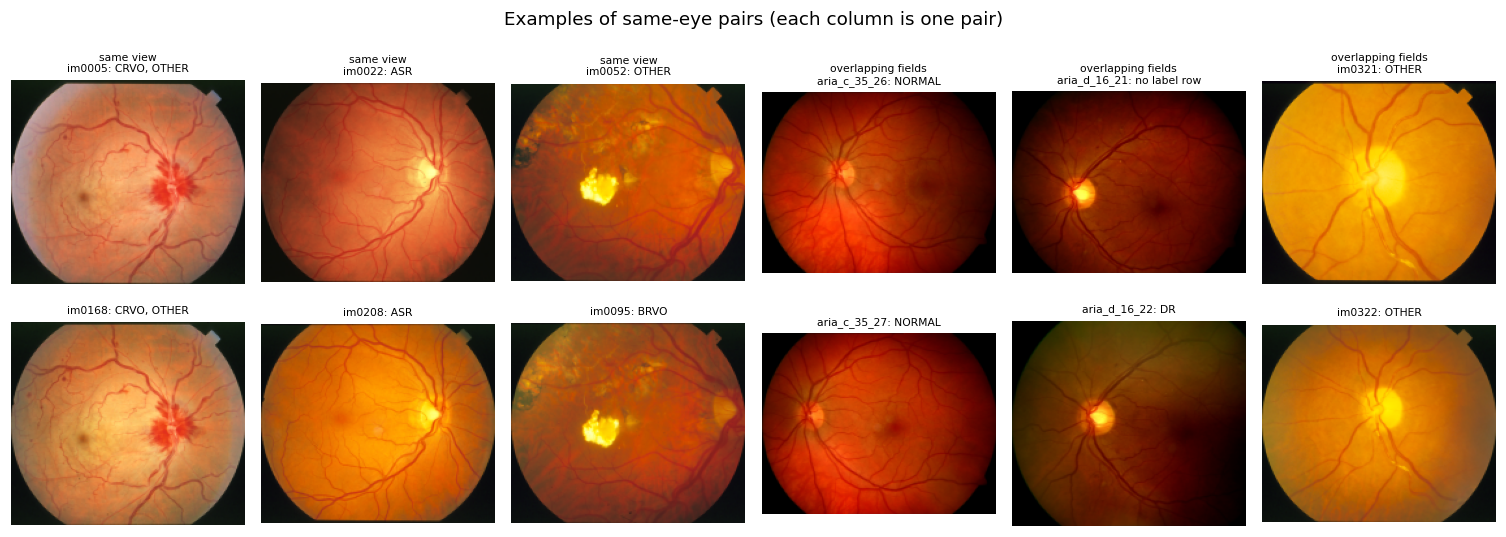

In [14]:
def thumb(stem, side=180):
    path = IMAGES / img.loc[img["stem"] == stem, "file"].iloc[0]
    arr = cv2.imdecode(np.fromfile(path, np.uint8), cv2.IMREAD_COLOR)
    h, w = arr.shape[:2]
    s = side / max(h, w)
    return cv2.cvtColor(cv2.resize(arr, (round(w * s), round(h * s)), interpolation=cv2.INTER_AREA), cv2.COLOR_BGR2RGB)


def labels_of(stem):
    if stem not in lab_vec.index:
        return "no label row"
    return ", ".join(l for l in LABELS if lab_vec.loc[stem, l] == 1)


examples = pd.concat([
    dups[dups["kind"] == "same view"].sort_values("alignment", ascending=False).head(3),
    dups[dups["kind"] == "overlapping fields"].sort_values("alignment", ascending=False).head(3),
])
fig, axes = plt.subplots(2, len(examples), figsize=(2.3 * len(examples), 5.2))
for j, r in enumerate(examples.itertuples()):
    for i, stem in enumerate([r.a, r.b]):
        axes[i, j].imshow(thumb(stem))
        head = f"{r.kind}\n" if i == 0 else ""
        axes[i, j].set_title(f"{head}{stem}: {labels_of(stem)}", fontsize=7)
        axes[i, j].axis("off")
fig.suptitle("Examples of same-eye pairs (each column is one pair)")
fig.tight_layout()
savefig(fig, "03_same_eye_pairs")
plt.show()

## 8. What the images look like

Random examples per source, then per label. 

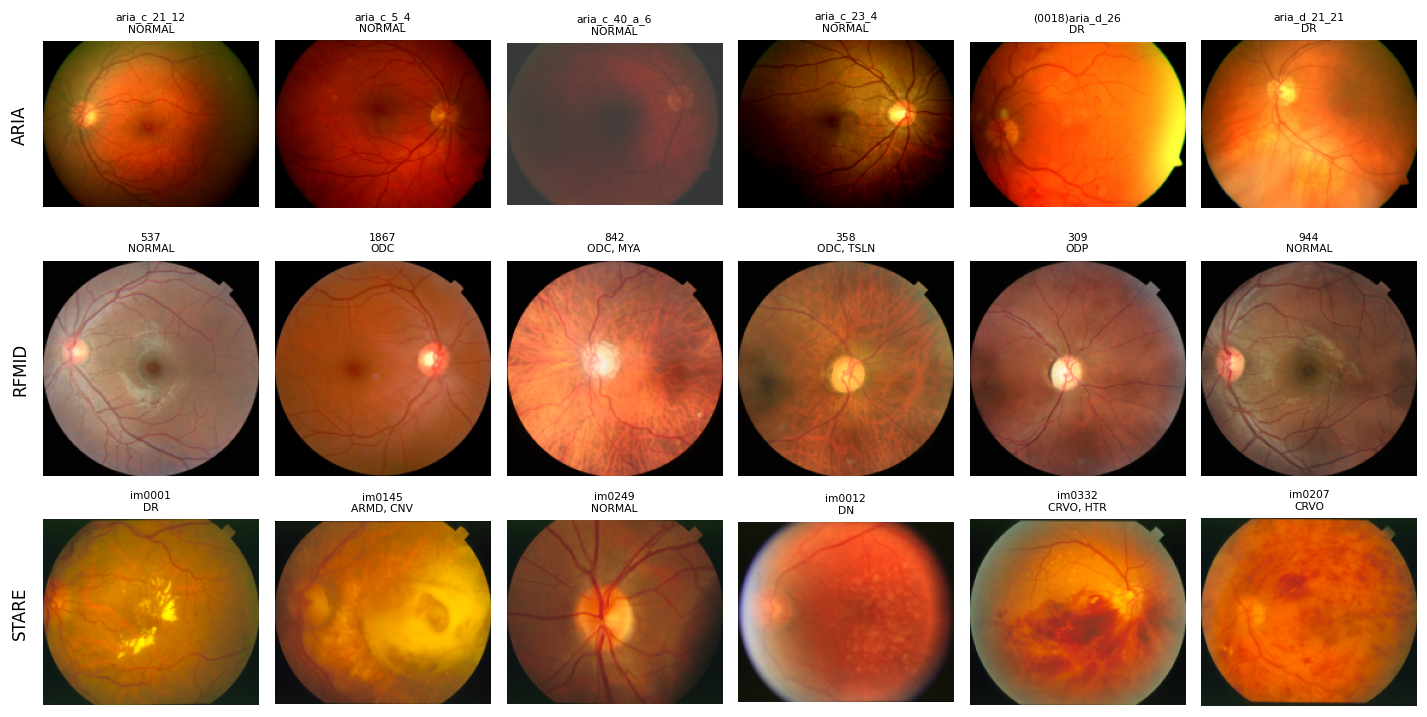

In [15]:
rng = np.random.default_rng(RNG_SEED)
fig, axes = plt.subplots(len(SOURCES), 6, figsize=(13, 6.8))
for i, s in enumerate(SOURCES):
    pick = rng.choice(lab.loc[lab["source"] == s, "ID"].values, size=6, replace=False)
    for j, stem in enumerate(pick):
        axes[i, j].imshow(thumb(stem))
        axes[i, j].set_title(f"{stem}\n{labels_of(stem)}", fontsize=7)
        axes[i, j].axis("off")
    axes[i, 0].text(-0.15, 0.5, s.upper(), transform=axes[i, 0].transAxes, rotation=90, va="center", fontsize=11)
fig.tight_layout()
savefig(fig, "04_samples_by_source")
plt.show()

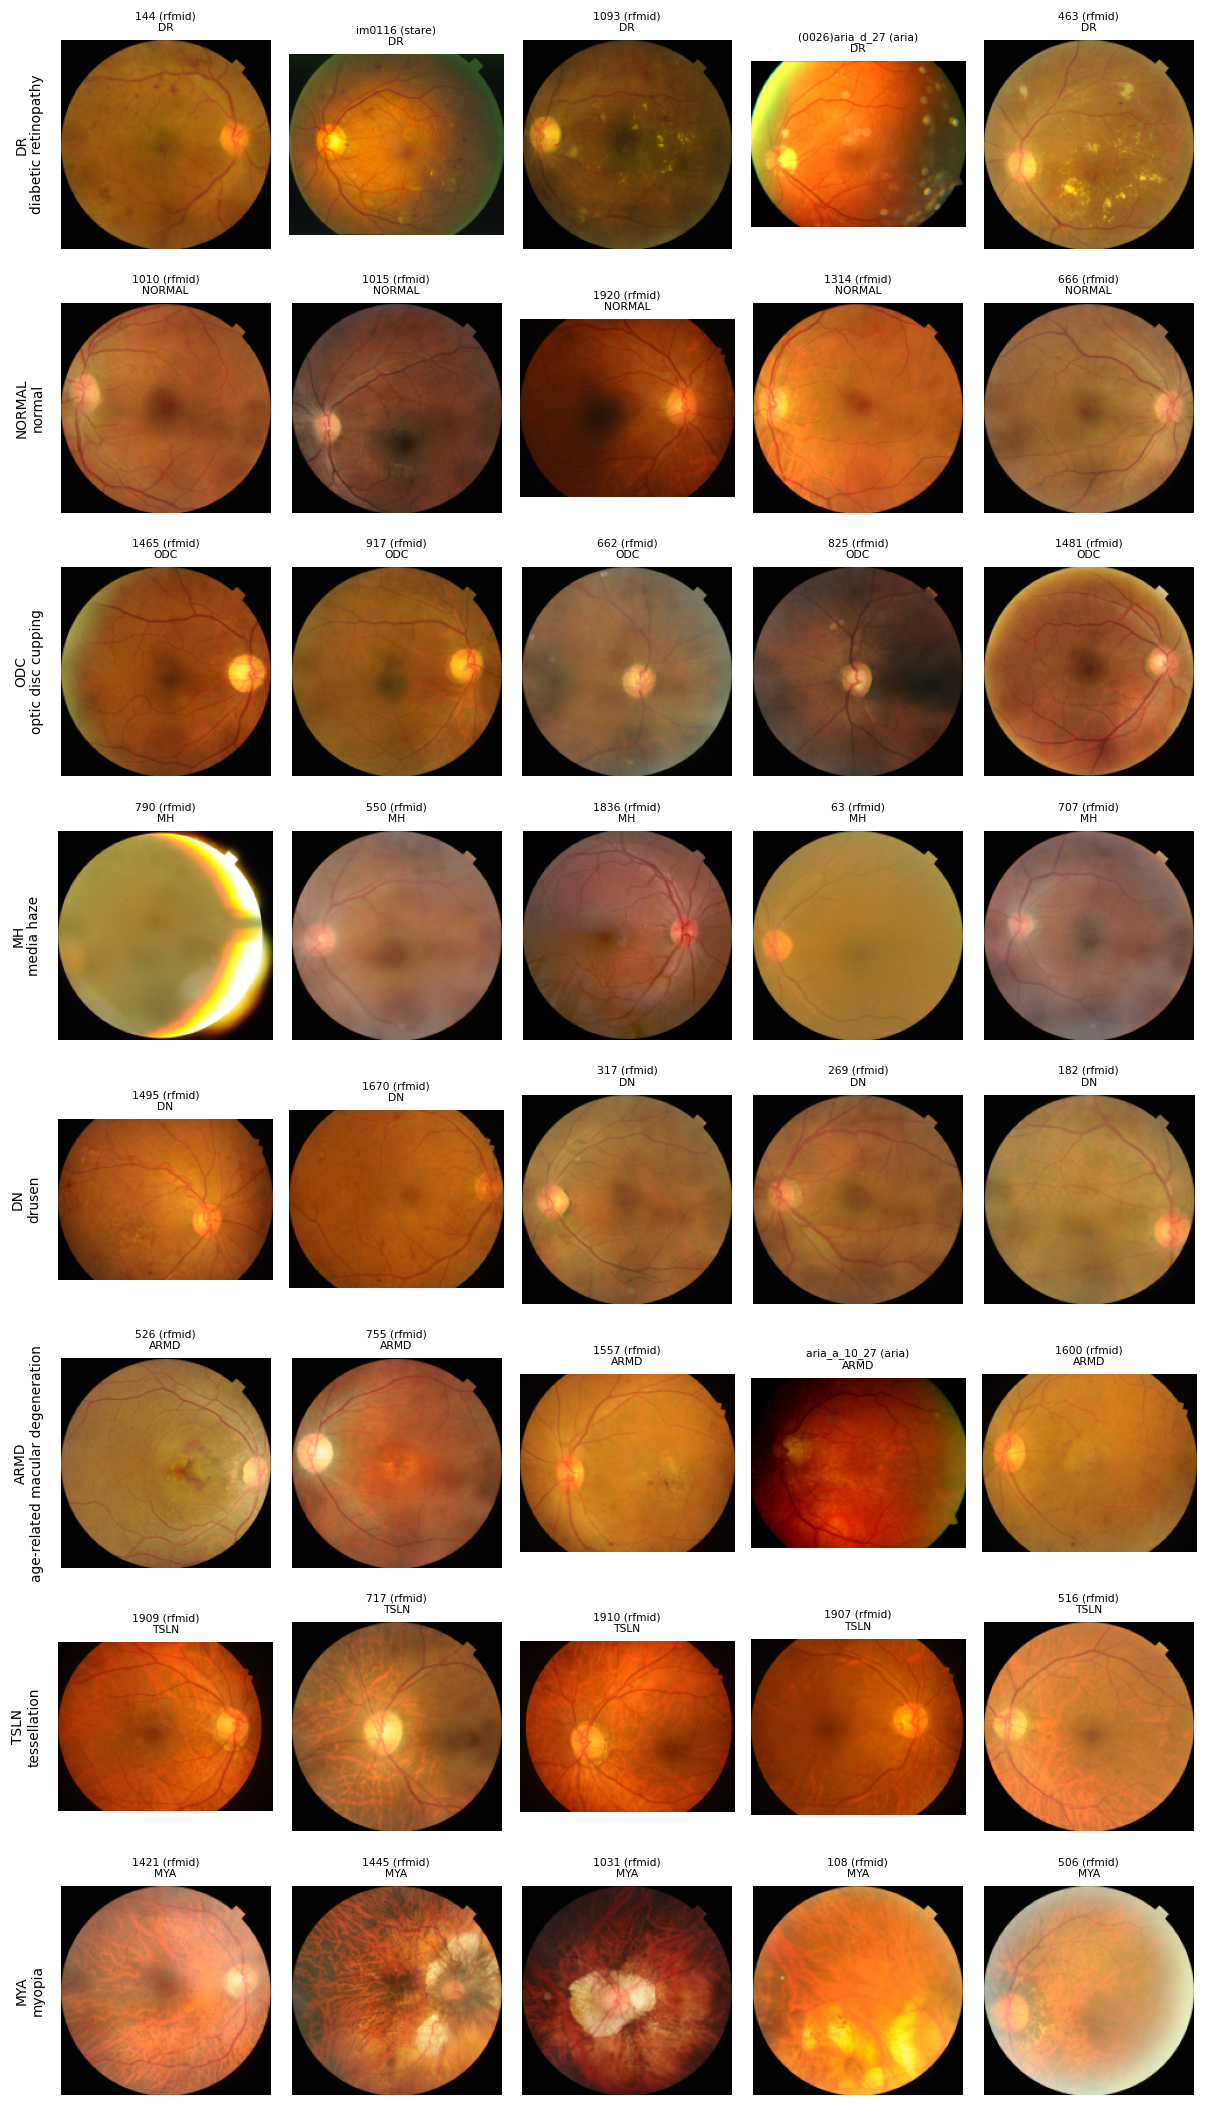

In [16]:
show_labels = [l for l in prev.index if l != "OTHER"][:8]
fig, axes = plt.subplots(len(show_labels), 5, figsize=(11, 2.4 * len(show_labels)))
for i, l in enumerate(show_labels):
    single_ids = lab.loc[(lab[l] == 1) & (lab[LABELS].sum(axis=1) == 1), "ID"].values
    pool = single_ids if len(single_ids) >= 5 else lab.loc[lab[l] == 1, "ID"].values
    pick = rng.choice(pool, size=min(5, len(pool)), replace=False)
    for j in range(5):
        axes[i, j].axis("off")
        if j < len(pick):
            stem = pick[j]
            axes[i, j].imshow(thumb(stem))
            axes[i, j].set_title(f"{stem} ({id_source(stem)})\n{labels_of(stem)}", fontsize=7)
    axes[i, 0].text(-0.15, 0.5, f"{l}\n{LABEL_NAMES[l]}", transform=axes[i, 0].transAxes,
                    rotation=90, va="center", ha="center", fontsize=9)
fig.tight_layout()
savefig(fig, "05_samples_by_label")
plt.show()